Lab 4: Intro to sklearn + Feature Transformations

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.anova import anova_lm
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler
import statsmodels.api as sm

Part 1: From statsmodels to scikit-learn (15 pts) 
In this portion of the lab, you will fit the following additive model body_mass_g ~ flipper_length_mm + C(sex) + C(species) in both statsmodels and sklearn, and use it to look more carefully at one-hot encoding and dummy variables (Week 4, slides 18–22). The goal of this exercise is to get more familiar with scikit-learn and one-hot encoding.

Question 1: [2 pts] Fit body_mass_g ~ flipper_length_mm + C(sex) + C(species) with statsmodels, as we have been doing in class. Report the coefficients and R². What is the reference level for sex and for species? Interpret the coefficient on C(species)[T.Gentoo] in one sentence. 

ANSWER:

Gentoo coeffiecients: 836.2600
The coefficient for flipper_length_mm is 20.029, and the model has an R^2 of 0.867. The reference level for sex is Female, and the reference level for species is Adelie. 

In [2]:
peng = pd.read_csv("../data/penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm"]
).reset_index(drop=True)

print(f"n = {len(peng)}")
peng.head()

n = 342


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [3]:
model = smf.ols('body_mass_g ~ flipper_length_mm + sex + species', data=peng).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     534.0
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          3.37e-142
Time:                        17:05:52   Log-Likelihood:                -2364.4
No. Observations:                 333   AIC:                             4739.
Df Residuals:                     328   BIC:                             4758.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -365.8174 

Question 2: Now fit the same model with sklearn’s LinearRegression. 

2a) sklearn does not accept formulas, so you need to build the predictor matrix X and the 
response y yourself. Create the dummy variables with pd.get_dummies(..., 
drop_first=True) and fit the model. Then, look at intercept_, coef_ for each 
coefficient, and R² using .score(). Confirm that they match your results from question 
1.

In [ ]:
X = pd.get_dummies(
    peng[["flipper_length_mm", "sex", "species"]],
    drop_first=True,
    dtype=int
)

y = peng["body_mass_g"]

model_sk = LinearRegression()
model_sk.fit(X, y)

print("Intercept:", model_sk.intercept_)
print("Coefficients:")
print(pd.Series(model_sk.coef_, index=X.columns))
print("R-squared:", model_sk.score(X, y))


Intercept: -357.18526532144097
Coefficients:
flipper_length_mm     20.013868
sex_male             529.824796
species_Chinstrap    -93.825092
species_Gentoo       823.691183
dtype: float64
R-squared: 0.8628402701404977


2b) Unlike statsmodels, sklearn does not calculate confidence intervals for the coefficients. 
How could we get these confidence intervals if we wanted them?

We can use bootstrapping if we wanted to calculate the confidence intervals. 

Question 3: [6 pts] In Week 4 (slide 22), we said that one-hot encoding and dummy variables are the same 
thing, and that the difference is a convention as to what is kept and what is dropped. We touched 
upon this briefly in class. Now we will explore this in more detail.  

3a)nRe-create X using pd.get_dummies() without drop_first (this matches 
OneHotEncoder() with its default settings). How many columns do you now have for 
sex, and for species?

ANSWER: 6 columns

In [ ]:
X_full = pd.get_dummies(
    peng[["flipper_length_mm", "sex", "species"]],
    drop_first=False,
    dtype=int
)

print(X_full.columns)
print("Number of predictor columns:", X_full.shape[1])


Index(['flipper_length_mm', 'sex_female', 'sex_male', 'species_Adelie',
       'species_Chinstrap', 'species_Gentoo'],
      dtype='str')
Number of predictor columns: 6


3b) Fit LinearRegression() with its default fit_intercept=True. Compare R² 
and the predicted values to question 2. Are they the same?

ANSWER: 
They are practically the same!

In [ ]:
#model with dummy variables
model_full = LinearRegression()
model_full.fit(X_full, y)

print("R-squared:", model_full.score(X_full, y))

#body mass
predictions = model_full.predict(X_full)

#predictions
print("First 5 predictions:", predictions[:10])


R-squared: 0.862848683606948
First 5 predictions: [3795.09650178 3364.54051403 3544.6343363  3504.61348691 3975.19032405
 3264.48839055 4075.24244754 3519.3668304  3459.33555631 3379.29385752]


3c) Compare the coefficients. Are they the same? Now calculate the differences between the 
Chinstrap and Adelie coefficients, the Gentoo and Adelie coefficients, and the male and 
female coefficients, and compare them to the coefficients we saw when we used dummy 
variables. What do you notice?  

ANSWER:

The table shows the coefficients difference of −93.33 grams for Chinstrap vs Adelie, 823.74 grams for Gentoo vs Adelie, and 530.61 grams for Male vs Female. These differences are close to the corresponding coefficients from the dummy variables. I noticed that even though they are similar, they still vary even though the data is the same.

In [ ]:
#coefficients
print(pd.Series(model_full.coef_, index=X_full.columns))

flipper_length_mm     20.010425
sex_female           -14.753343
sex_male             515.854768
species_Adelie      -243.484856
species_Chinstrap   -336.814186
species_Gentoo       580.299042
dtype: float64


In [ ]:
coefficients = pd.Series(model_full.coef_, index=X_full.columns)

#chin vs ade
print("Chinstrap - Adelie:",
      coefficients["species_Chinstrap"] - coefficients["species_Adelie"])

#gen vs ade
print("Gentoo - Adelie:",
      coefficients["species_Gentoo"] - coefficients["species_Adelie"])

#sex
print("Male - Female:",
      coefficients["sex_male"] - coefficients["sex_female"])


Chinstrap - Adelie: -93.32932990304695
Gentoo - Adelie: 823.7838981984278
Male - Female: 530.6081112353892


3d) Explain what is going on. Why do you need to be careful about encoding? 

The model make predictions, but the individual coefficients are unknown. Dropping categories from the categorical variable avoids this and allowsthe coefficients to be understood easily. 

Question 4: [4 pts] In practice, sklearn users usually do not call pd.get_dummies() by hand. Instead, 
they bundle the encoding and the model together in a pipeline so the exact same steps are applied 
to any new data being used for predictions. Using the sklearn Pipeline functionality is an 
important conceptual and practical step. Model development pipelines, whether in sklearn or 
another framework, are a critical part of the practice of data science. 

4a) Build a Pipeline that uses a ColumnTransformer to pass flipper_length_mm 
through unchanged and apply OneHotEncoder(drop="first") to sex and 
species, followed by LinearRegression(). Fit it on the penguin DataFrame 
directly. Use get_feature_names_out() on the ColumnTransformer to 
confirm that the columns and coefficients are the same as in Question 2.

In [ ]:
#predictors
X = peng[["flipper_length_mm", "sex", "species"]]

#outcome
y = peng["body_mass_g"]

#categorical org
transformer = ColumnTransformer([
    ("categorical", OneHotEncoder(drop="first"), ["sex", "species"])
], remainder="passthrough")

#pipeline
model_pipe = Pipeline([
    ("transform", transformer),
    ("regression", LinearRegression())
])

#model
model_pipe.fit(X, y)

print("R-squared:", model_pipe.score(X, y))


R-squared: 0.862848683606948


4b) Using this model, predict body mass for a male Gentoo penguin with a flipper length of 
215 mm, and verify this prediction by hand using your coefficients from Question 1. You 
can use your coefficients from either the statsmodels or sklearn model

In [ ]:
# new peng df
new_penguin = pd.DataFrame({
    "flipper_length_mm": [215],
    "sex": ["male"],
    "species": ["Gentoo"]
})

#body mass
prediction = model_pipe.predict(new_penguin)

print("Predicted body mass:", prediction[0], "grams")


Predicted body mass: 5299.234839668335 grams


PART 2: Scaling and Variable Transformations (18 pts)

In Lab 2, you used planet data and a log transformation to derive Kepler’s law. In Lab 3, you read more 
about feature transformations. In this exercise, we will explore transformations a bit more and look at how 
transforming data changes the model. There are two different kinds of transformations we will explore. 
The first is linear transformations (changing units, centering, standardizing, min-max scaling). These 
transformations linearly stretch and shift a variable without changing its shape. Nonlinear 
transformations, like the log transformation we used for the planets data in Lab 2, change the shape of the 
data. These have very different effects on a linear model, and one of them is essential for recursive feature 
elimination (RFE).

Notes: For questions 1–3, use the 333 penguins from Part 1 and the model body_mass_g ~ 
flipper_length_mm + bill_length_mm + bill_depth_mm.  

Question 1: Fit the model with sklearn using the original units, and report the coefficients and R².

1a) RFE works by fitting the model, ranking the features by the absolute value of their 
coefficients, and dropping the smallest one. Based on your coefficients, which feature 
would RFE drop first? 

ANSWER: bill_length_mm would be dropped first because it has the smallest coefficient. 

In [ ]:
#predictors
X = peng[["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]]

#outcome
y = peng["body_mass_g"]

#linear reg model
model = LinearRegression()
model.fit(X, y)

#coefficients
print("Intercept:", model.intercept_)
print(pd.Series(model.coef_, index=X.columns))

print("R-squared:", model.score(X, y))



Intercept: -6424.764698098588
flipper_length_mm    50.269222
bill_length_mm        4.161820
bill_depth_mm        20.049533
dtype: float64
R-squared: 0.7614704841272495


1b) Now convert bill_length_mm to centimeters (divide by 10) and refit. What happens to the coefficients, R², and predictions? Which feature would RFE drop first now? 

ANSWER: bill_depth_mm would be dropped first because it has the smallest coefficient. 

In [ ]:
#original predictions
original_predictions = model.predict(X)

#copy predictors
X_cm = X.copy()

#bill length conversion
X_cm["bill_length_cm"] = X_cm["bill_length_mm"] / 10

#remove the old bill length column
X_cm = X_cm.drop(columns=["bill_length_mm"])

#new model
model_cm = LinearRegression()
model_cm.fit(X_cm, y)

#new coefficients
print(pd.Series(model_cm.coef_, index=X_cm.columns))

#R-squared
print("New R-squared:", model_cm.score(X_cm, y))

#new predictions
new_predictions = model_cm.predict(X_cm)

print("Original prediction:", original_predictions[0])
print("New prediction:", new_predictions[0])



flipper_length_mm    50.269222
bill_depth_mm        20.049533
bill_length_cm       41.618205
dtype: float64
New R-squared: 0.7614704841272493
Original prediction: 3211.617868374018
New prediction: 3211.6178683740163


Question 2: Now standardize the three predictors and refit, using 
make_pipeline(StandardScaler(), LinearRegression()). 

2a) Report the coefficients, and interpret the coefficient on flipper length in words. (Hint: 
what is “one unit” of a standardized variable?)

ANSWER: The coefficient for flipper_length_mm is 705.837207, which means that there is a one standard deviation of increase in the flipper length for body mass. 

In [ ]:
#linear regression
model_scaled = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

#model
model_scaled.fit(X, y)

#coefficients from the regression model
scaled_coefficients = model_scaled.named_steps["linearregression"].coef_

#coefficients
print(pd.Series(scaled_coefficients, index=X.columns))

#R-squared
print("R-squared:", model_scaled.score(X, y))


flipper_length_mm    705.837207
bill_length_mm        22.688564
bill_depth_mm         39.535753
dtype: float64
R-squared: 0.7614704841272493


2b) Rank the features by the absolute value of their standardized coefficients. Which would 
RFE drop first? Repeat with bill length in centimeters. Does the unit conversion matter 
now? Why or why not?

ANSWER: The feature with the smallest standardized coefficient is bill_length_cm, so RFE would drop it first. Converting bill length from mm to cm does not change the standardized coefficients because StandardScaler standardizes each value. 

In [ ]:
#standardize the predictors in cm
scaler_cm = StandardScaler()
X_cm_scaled = scaler_cm.fit_transform(X_cm)

#regression model
model_cm_scaled = LinearRegression()
model_cm_scaled.fit(X_cm_scaled, y)

#coefficients
print(pd.Series(model_cm_scaled.coef_, index=X_cm.columns))

#R-squared
print("R-squared:", model_cm_scaled.score(X_cm_scaled, y))


flipper_length_mm    705.837207
bill_depth_mm         39.535753
bill_length_cm        22.688564
dtype: float64
R-squared: 0.7614704841272493


2c) Repeat the model fitting but replace StandardScaler with MinMaxScaler and RobustScaler instead of StandardScaler. Do the three scalers agree on the ranking? On the magnitudes? What is each scaler using as its “unit”? 

ANSWER: The three scalers agree on the ranking, but the coefficient magnitudes differ because each scaler predictor is changed differently. StandardScaler uses the standard deviation, MinMaxScaler uses the minimum and maximum values, and RobustScaler uses IQR.

In [ ]:
# MinMaxScaler
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

model_minmax = LinearRegression()
model_minmax.fit(X_minmax, y)

print("MinMaxScaler coefficients:")
print(pd.Series(model_minmax.coef_, index=X.columns))
print("R-squared:", model_minmax.score(X_minmax, y))


# RobustScaler
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

model_robust = LinearRegression()
model_robust.fit(X_robust, y)

print("RobustScaler coefficients:")
print(pd.Series(model_robust.coef_, index=X.columns))
print("R-squared:", model_robust.score(X_robust, y))


MinMaxScaler coefficients:
flipper_length_mm    2965.884077
bill_length_mm        114.450063
bill_depth_mm         168.416078
dtype: float64
R-squared: 0.7614704841272493
RobustScaler coefficients:
flipper_length_mm    1156.192098
bill_length_mm         38.600885
bill_depth_mm          62.153553
dtype: float64
R-squared: 0.7614704841272493


2d) Repeat the model fitting, but instead of using a Scaler, center the predictors (subtract the mean, but do not divide by the standard deviation) 

In [49]:
# Center the predictors by subtracting their means
X_centered = X - X.mean()

# Fit the regression model
model_centered = LinearRegression()
model_centered.fit(X_centered, y)

# Print the coefficients
print("Centered coefficients:")
print(pd.Series(model_centered.coef_, index=X.columns))

# Print R-squared
print("R-squared:", model_centered.score(X_centered, y))

Centered coefficients:
flipper_length_mm    50.269222
bill_length_mm        4.161820
bill_depth_mm        20.049533
dtype: float64
R-squared: 0.7614704841272493


QUESTION 3: [6 pts] Build a table with one row for each of the following versions of the model: (i) original 
units,  (ii) bill length in cm, (iii) centered predictors, (iv) StandardScaler and (v) 
MinMaxScaler. The columns should include: coefficients, intercept, R2. 

3a) Add three columns to the table that indicate whether each of the following changed 
relative to (i): the coefficients, the intercept, R², and the predicted values. The first row 
should be False (since comparing a model with itself should always result in no change!)

In [51]:
# Add coefficients to the table
table["Coefficients"] = [
    model.coef_,
    model_cm.coef_,
    model_centered.coef_,
    model_scaled.named_steps["linearregression"].coef_,
    model_minmax.coef_
]

table

,Model,Intercept,R-squared,Coefficients
0,Original,-6424.764698,0.76147,"[50.26922163824042, 4.161820470411504, 20.0495..."
1,Bill length in cm,-6424.764698,0.76147,"[50.26922163824043, 20.049533131443987, 41.618..."
2,Centered,4201.754386,0.76147,"[50.26922163824044, 4.161820470411498, 20.0495..."
3,StandardScaler,4201.754386,0.76147,"[705.8372072960946, 22.6885639256088, 39.53575..."
4,MinMaxScaler,2617.784745,0.76147,"[2965.884076656185, 114.45006293631504, 168.41..."


In [52]:
table["Coefficients changed"] = [
    False,
    True,
    False,
    True,
    True
]

table["Intercept changed"] = [
    False,
    False,
    True,
    True,
    True
]

table

,Model,Intercept,R-squared,Coefficients,Coefficients changed,Intercept changed
0,Original,-6424.764698,0.76147,"[50.26922163824042, 4.161820470411504, 20.0495...",False,False
1,Bill length in cm,-6424.764698,0.76147,"[50.26922163824043, 20.049533131443987, 41.618...",True,False
2,Centered,4201.754386,0.76147,"[50.26922163824044, 4.161820470411498, 20.0495...",False,True
3,StandardScaler,4201.754386,0.76147,"[705.8372072960946, 22.6885639256088, 39.53575...",True,True
4,MinMaxScaler,2617.784745,0.76147,"[2965.884076656185, 114.45006293631504, 168.41...",True,True


In [53]:
table["R-squared changed"] = [
    False,
    False,
    False,
    False,
    False
]

table

,Model,Intercept,R-squared,Coefficients,Coefficients changed,Intercept changed,R-squared changed
0,Original,-6424.764698,0.76147,"[50.26922163824042, 4.161820470411504, 20.0495...",False,False,False
1,Bill length in cm,-6424.764698,0.76147,"[50.26922163824043, 20.049533131443987, 41.618...",True,False,False
2,Centered,4201.754386,0.76147,"[50.26922163824044, 4.161820470411498, 20.0495...",False,True,False
3,StandardScaler,4201.754386,0.76147,"[705.8372072960946, 22.6885639256088, 39.53575...",True,True,False
4,MinMaxScaler,2617.784745,0.76147,"[2965.884076656185, 114.45006293631504, 168.41...",True,True,False


In [54]:
table["Predictions changed"] = [
    False,
    False,
    False,
    False,
    False
]

table

,Model,Intercept,R-squared,Coefficients,Coefficients changed,Intercept changed,R-squared changed,Predictions changed
0,Original,-6424.764698,0.76147,"[50.26922163824042, 4.161820470411504, 20.0495...",False,False,False,False
1,Bill length in cm,-6424.764698,0.76147,"[50.26922163824043, 20.049533131443987, 41.618...",True,False,False,False
2,Centered,4201.754386,0.76147,"[50.26922163824044, 4.161820470411498, 20.0495...",False,True,False,False
3,StandardScaler,4201.754386,0.76147,"[705.8372072960946, 22.6885639256088, 39.53575...",True,True,False,False
4,MinMaxScaler,2617.784745,0.76147,"[2965.884076656185, 114.45006293631504, 168.41...",True,True,False,False


3b) Fit (i) and (iv) in statsmodels and compare the t-statistics and p-values for the slopes. 
What do you notice? What does this tell you about how linear scaling impacts model 
coefficients and predictions.  

ANSWER: 
So, t-statistics and p-values for the slopes stayed aliked after standardizing the predictors. This shows that linear scaling impacts the coefficients, but it does not impact the prediction model.
flipper_length_mm: t = 20.293, p = 0.000
bill_length_mm: t = 0.781, p = 0.435
bill_depth_mm: t = 1.464, p = 0.144

In [57]:
#add intercept
X_original_sm = sm.add_constant(X)

#original model
original_sm = sm.OLS(y, X_original_sm).fit()

print(original_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        23:18:36   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -6424.7647    561.46

In [59]:
#standardize x
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#add intercept
X_scaled_sm = sm.add_constant(X_scaled)

#model
scaled_sm = sm.OLS(y, X_scaled_sm).fit()

print(scaled_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        23:20:03   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4201.7544     21.273    197.517      0.0

3c) Rebuild the original model, but this time, take the log of the predictors. Add this row to 
your table above. Comment on differences you observe between the linear 
transformations and this one

ANSWER: The log transformation has a different coefficients, intercept, R-squared, and predictions compared to the linear transformations. There is a change in the relationship between the predictors and body mass for log tranformation. 

In [60]:
#log
X_log = np.log(X)

#model
model_log = LinearRegression()
model_log.fit(X_log, y)

print(pd.Series(model_log.coef_, index=X.columns))

print("Intercept:", model_log.intercept_)
print("R-squared:", model_log.score(X_log, y))

flipper_length_mm    9957.880502
bill_length_mm        260.467910
bill_depth_mm         258.828114
dtype: float64
Intercept: -50296.69719703896
R-squared: 0.7529680289105357


In [65]:
table.loc[len(table)] = [
    "Log",
    model_log.intercept_,
    model_log.score(X_log, y),
    model_log.coef_,
    True,
    True,
    True,
    True
]

table

,Model,Intercept,R-squared,Coefficients,Coefficients changed,Intercept changed,R-squared changed,Predictions changed
0,Original,-6424.764698,0.761470,"[50.26922163824042, 4.161820470411504, 20.0495...",False,False,False,False
1,Bill length in cm,-6424.764698,0.761470,"[50.26922163824043, 20.049533131443987, 41.618...",True,False,False,False
2,Centered,4201.754386,0.761470,"[50.26922163824044, 4.161820470411498, 20.0495...",False,True,False,False
3,StandardScaler,4201.754386,0.761470,"[705.8372072960946, 22.6885639256088, 39.53575...",True,True,False,False
4,MinMaxScaler,2617.784745,0.761470,"[2965.884076656185, 114.45006293631504, 168.41...",True,True,False,False
5,Log,-50296.697197,0.752968,"[9957.88050204061, 260.4679100170893, 258.8281...",True,True,NaN,True
6,Log,-50296.697197,0.752968,"[9957.88050204061, 260.4679100170893, 258.8281...",True,True,NaN,True
7,Log,-50296.697197,0.752968,"[9957.88050204061, 260.4679100170893, 258.8281...",True,True,True,True


QUESTION 4:  pts] Now we will switch to the bike data and look at the number of casual riders to further 
explore non-linear transfor

4a) Plot a histogram of count of casual riders. On the x-axis should be the count of casual 
riders, and the y-axis is the number of days with that number of riders. Comment on the 
shape of this plot. 

ANSWER: It appears to be a smooth plot and the distribution is heavily skewed right. 

In [67]:
bike = pd.read_csv("../data/bike-sharing-daily.csv", parse_dates=["dteday"])
print(bike.shape)
print(bike.dtypes)
bike.head()

(731, 16)
instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


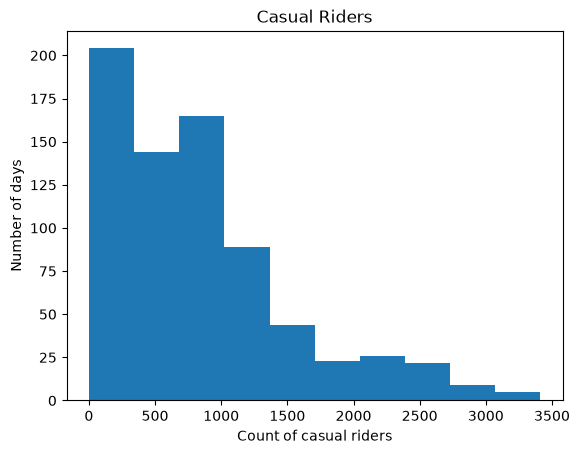

In [69]:
#histogram
plt.hist(bike["casual"])

plt.xlabel("Count of casual riders")
plt.ylabel("Number of days")
plt.title("Casual Riders")

plt.show()

4b) Fit casual ~ temp + hum + windspeed + workingday and plot fitted values vs. residuals. 
What do you see?

ANSWER: 
The residuals are randomly scattered around the whole graph. It is heavily spread apart when the fitted values start increasing.

In [ ]:
#model
bike_model = smf.ols(
    "casual ~ temp + hum + windspeed + workingday",
    data=bike
).fit()

In [ ]:
#fitted values and residuals
fitted = bike_model.fittedvalues
residuals = bike_model.resid

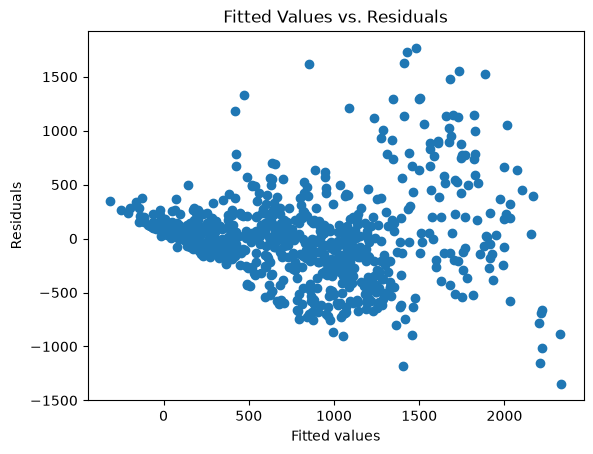

In [73]:
#plot
plt.scatter(fitted, residuals)

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs. Residuals")

plt.show()

4c) Fit the same model with log(casual) as the response. (Check whether casual contains any 
zeros first. If it does, use np.log1p.) Plot the histogram and fitted vs. residuals again. 
What changed? 

ANSWER: The log transformation more spread out and in a shape of an upside down U. The histogram shows that the data is not skewed on either side.

In [74]:
(bike["casual"] == 0).sum()

np.int64(0)

In [75]:
log_casual = np.log(bike["casual"])

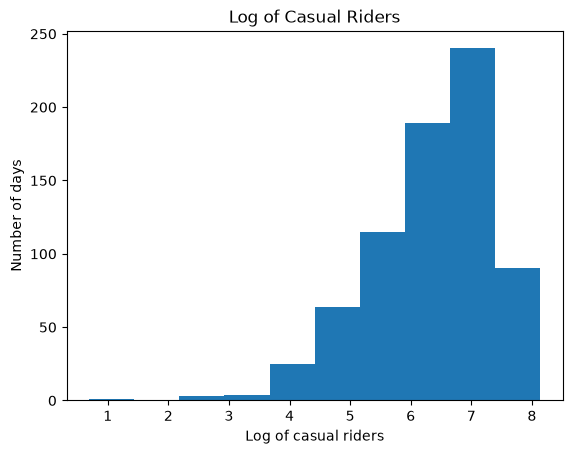

In [76]:
plt.hist(log_casual)

plt.xlabel("Log of casual riders")
plt.ylabel("Number of days")
plt.title("Log of Casual Riders")

plt.show()

In [77]:
log_model = sm.OLS.from_formula(
    "log_casual ~ temp + hum + windspeed + workingday",
    data=bike.assign(log_casual=log_casual)
).fit()

In [78]:
log_fitted = log_model.fittedvalues
log_residuals = log_model.resid

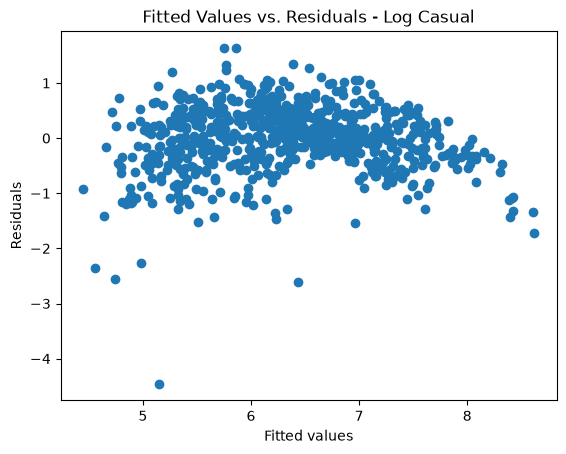

In [79]:
plt.scatter(log_fitted, log_residuals)

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs. Residuals - Log Casual")

plt.show()

4d) Based on our readings from last week, did it make sense to do the log transformation on 
the target variable, based on the original histogram shape? Based on the plots in part c, 
did this have the impact you expected? How does this compare with what we did 
previously for Kepler’s Law? 

ANSWER: 
The log transformation did make sense since the original histogram showed how it was heavily skewed right. When log was performed the histogram showed that it was more spread out and not skewed on either side. This was the expected since the log transformation made the larger values into more smaller values, which is like Kepler’s Law compared to the log transformation. 

AI USAGE for question 1 and 2:
I used GenAI to help explain concepts such as linear regression, RFE, Standard Scaler, and MinMaxScaler, and Robust Scaler, by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

PART 3: FINAL PROJECT

Fiona St.Clair is submitting our group’s final project update. She will be submitting it as a separate document on Canvas